# Добавление атрибута

Добавим почасовую ставку

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("mental_health_dataset.csv")

df["Mental_Health_Status"] = df["Mental_Health_Status"].map(
    {
        "Healthy": 2,
        "Needs Attention": 1,
        "Critical": 0
    }
)

df["Remote_Work"] = df["Remote_Work"].map({"No": 0, "Hybrid": 1, "Yes": 2})

df["Hourly_Rate_USD"] = df["Monthly_Income_USD"] / (df["Work_Hours_Per_Week"] * 52 / 12)

# "Причесывание" датасета

Выбросов в прошлой ЛР не обнаружено. Удалим дубли

In [5]:
print("Дублей:", df.duplicated().sum())
df = df.drop_duplicates().reset_index(drop=True)

Дублей: 0


Удаление строк с кривыми и пропущенными значениями значениями

In [11]:
print("Строк до:", len(df))
df = df[
    df["Age"].between(18, 100)
    & df["Sleep_Hours"].between(4, 15)
    & df["Work_Hours_Per_Week"].between(0, 100)
    & (df["Monthly_Income_USD"] >= 0)
    & (df["Hourly_Rate_USD"] >= 0)
    & df["Screen_Time_Hours"].between(0, 20)
    & df["Physical_Activity_Hours"].between(0, 20)
    & df["Depression_Score"].between(0, 100)
    & df["Mood_Score"].between(0, 100)
    & df["Emotional_Stability"].between(0, 100)
]
df.dropna(inplace=True)
print("После:", len(df))

Строк до: 43985
После: 42937


# Графики зависимости

78 пар


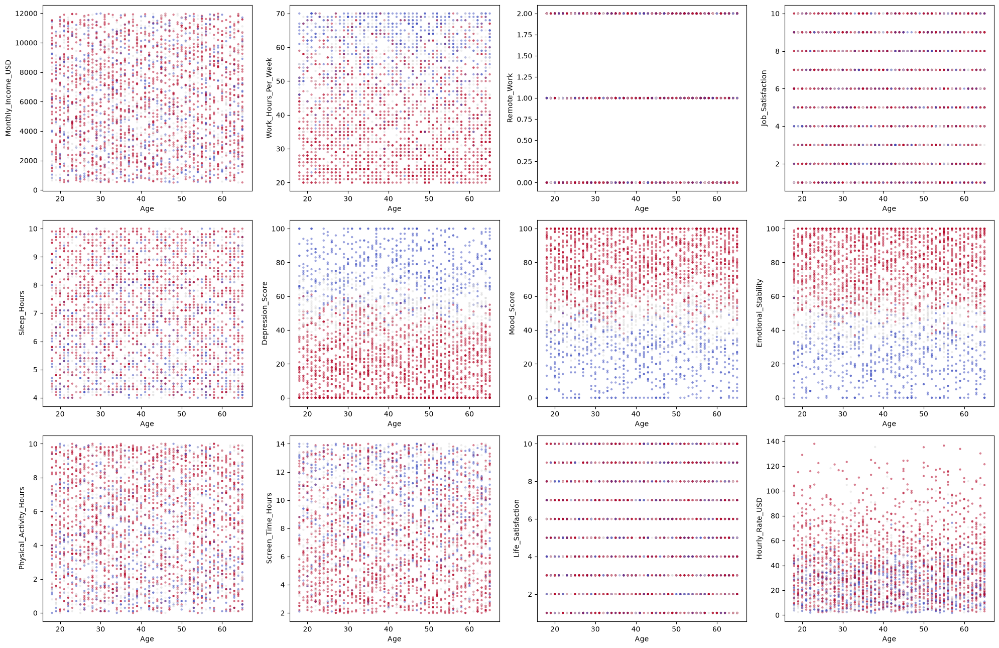

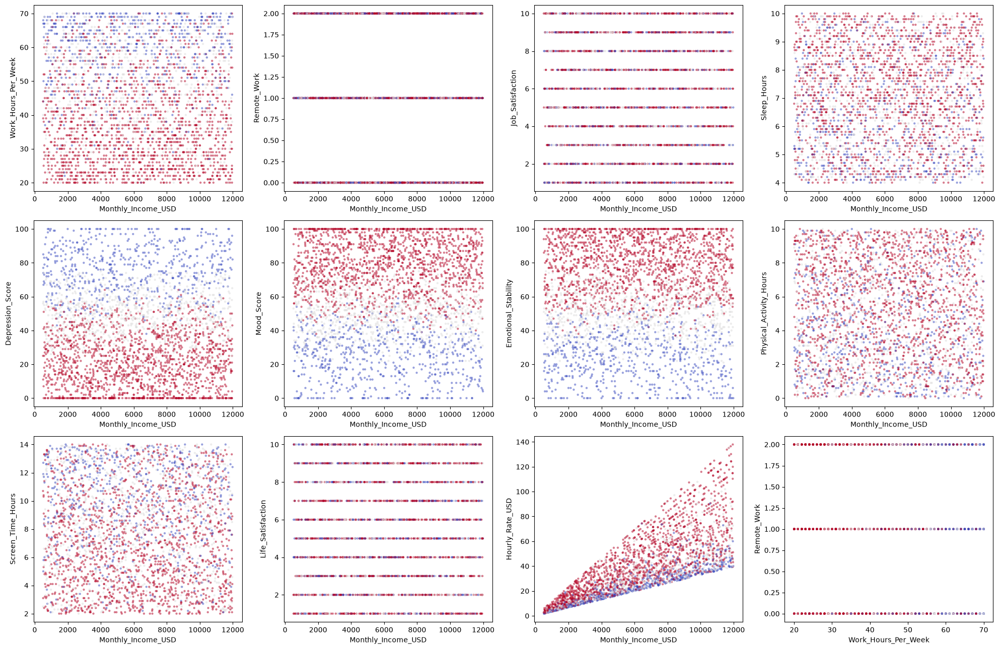

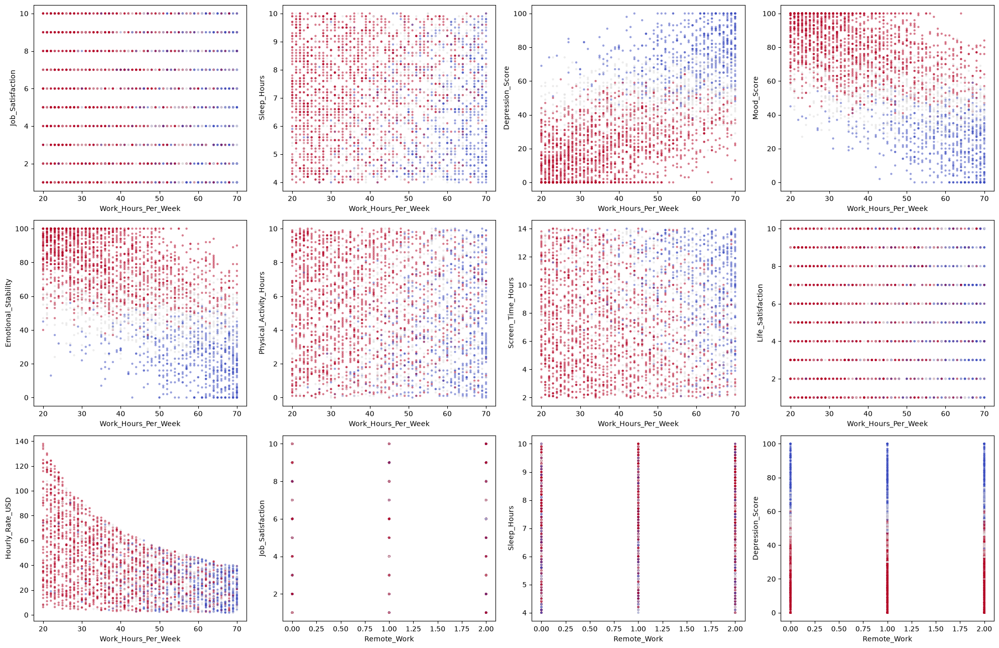

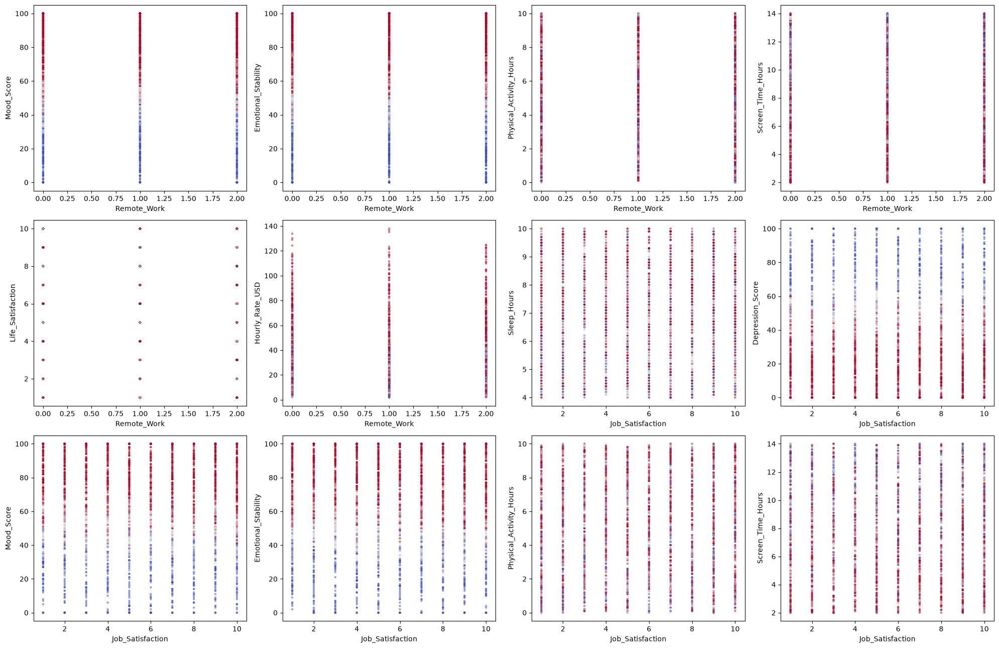

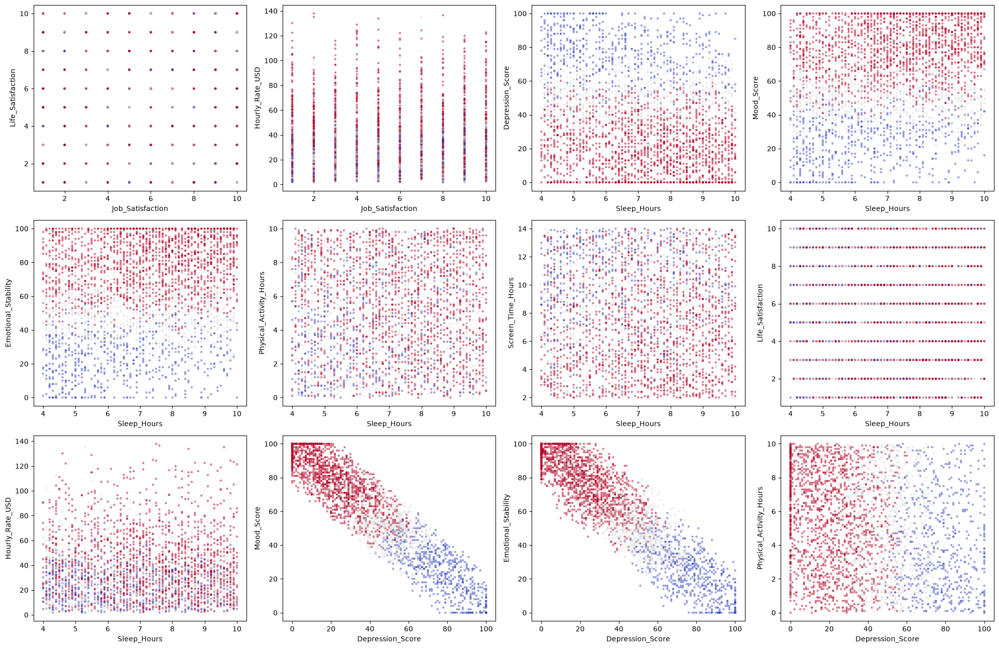

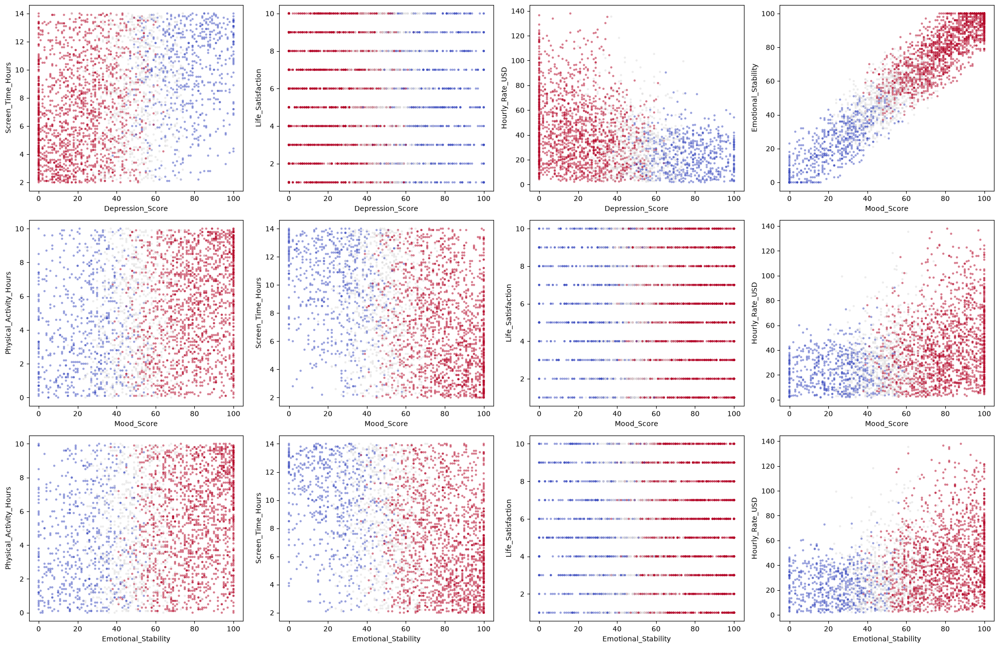

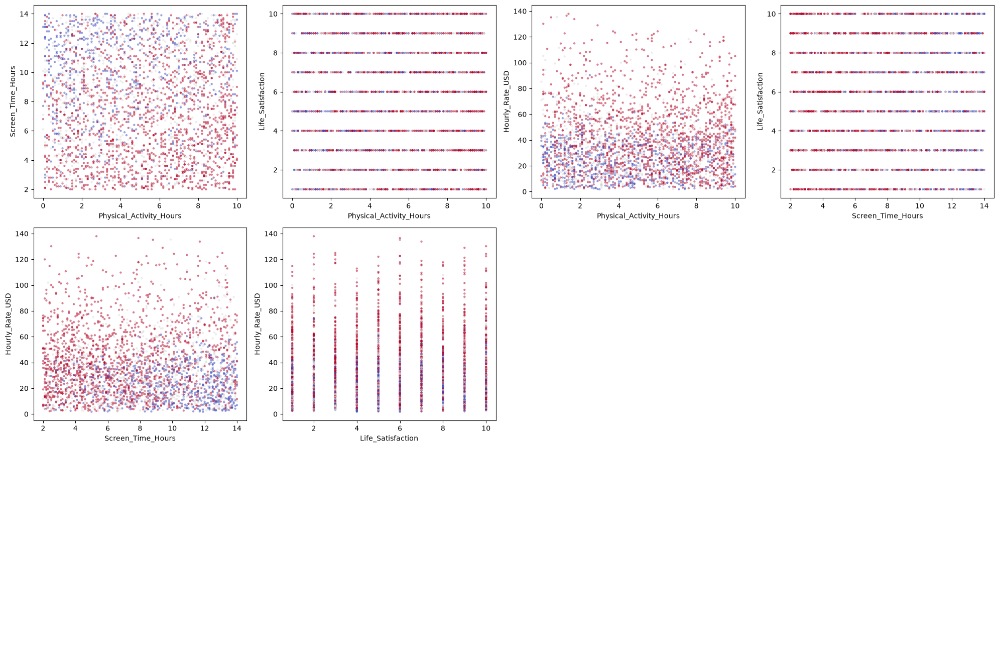

In [12]:
from itertools import combinations

d = df.sample(3000, random_state=1)
cols = [c for c in df.columns if c != "Mental_Health_Status"]
pairs = list(combinations(cols, 2))
print(len(pairs), "пар")

per_fig = 12     
for i in range(0, len(pairs), per_fig):
    chunk = pairs[i:i + per_fig]
    fig, axes = plt.subplots(3, 4, figsize=(20, 13))
    for ax, (x, y) in zip(axes.flat, chunk):
        ax.scatter(d[x], d[y], c=d["Mental_Health_Status"], cmap="coolwarm", s=5, alpha=0.4)
        ax.set_xlabel(x)
        ax.set_ylabel(y)
    for ax in axes.flat[len(chunk):]:
        ax.axis("off")
    plt.tight_layout()
    plt.show()

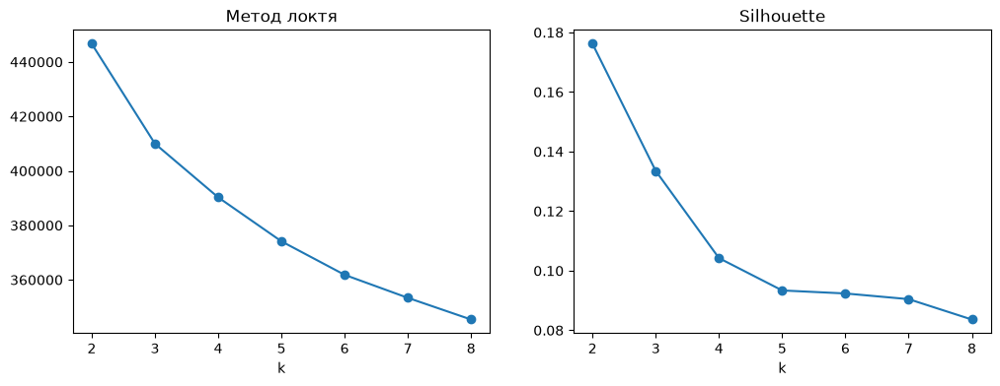

Mental_Health_Status     0     1      2
cluster                                
0                       70  2067   9706
1                       16  2618  10975
2                     8915  7418   1152
Mental_Health_Status     0     1     2
cluster                               
0                     0.01  0.17  0.82
1                     0.00  0.19  0.81
2                     0.51  0.42  0.07
          Age  Monthly_Income_USD  Work_Hours_Per_Week  Remote_Work  \
cluster                                                               
0        41.5              9168.9                 33.3          1.0   
1        41.3              3713.3                 40.8          1.0   
2        41.5              6253.9                 55.9          1.0   

         Job_Satisfaction  Sleep_Hours  Depression_Score  Mood_Score  \
cluster                                                                
0                     5.5          7.1              22.3        77.8   
1                     5.5        

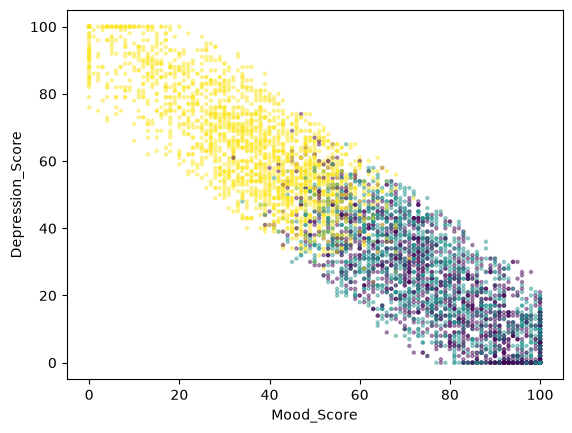

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

# 1. Признаки: все числовые, кроме таргета
X = df.drop(columns=["Mental_Health_Status"]).select_dtypes(include="number")

# 2. Масштабирование (обязательно: доход в тысячах, шкалы 0-100, возраст 18-65)
X_scaled = StandardScaler().fit_transform(X)

# 3. Подбор числа кластеров
ks = range(2, 9)
inertia, sil = [], []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=1).fit(X_scaled)
    inertia.append(km.inertia_)
    sil.append(silhouette_score(X_scaled, km.labels_, sample_size=5000, random_state=1))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(ks, inertia, "o-"); ax[0].set_title("Метод локтя"); ax[0].set_xlabel("k")
ax[1].plot(ks, sil, "o-");     ax[1].set_title("Silhouette");   ax[1].set_xlabel("k")
plt.show()

# 4. Итоговая модель (k=3, по числу классов статуса)
km = KMeans(n_clusters=3, n_init=10, random_state=1)
df["cluster"] = km.fit_predict(X_scaled)

# 5. Сравнение с настоящим статусом
print(pd.crosstab(df["cluster"], df["Mental_Health_Status"]))
print(pd.crosstab(df["cluster"], df["Mental_Health_Status"], normalize="index").round(2))

# 6. Портрет кластеров (средние значения признаков)
print(df.groupby("cluster")[X.columns].mean().round(1))

# 7. Визуализация на паре ключевых признаков
d = df.sample(5000, random_state=1)
plt.scatter(d["Mood_Score"], d["Depression_Score"], c=d["cluster"], cmap="viridis", s=5, alpha=0.4)
plt.xlabel("Mood_Score"); plt.ylabel("Depression_Score")
plt.show()